In [8]:
# import libraries
from cil.optimisation.functions import TotalVariation, L2NormSquared
from cil.framework import ImageGeometry, BlockDataContainer
from cil.utilities.dataexample import TestData
from cil.utilities.display import plotter2D
from cil.processors import Resizer

from skimage import data
from skimage.color import rgb2gray

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load chelsea image from skimage
image = data.astronaut().astype("float32")/255.0


In [11]:
# Setup the image domain and fill the image into an ImageData
ig = ImageGeometry(voxel_num_y=image.shape[1], voxel_num_x=image.shape[0], channels=image.shape[2],
                  dimension_labels=['horizontal_x', 'horizontal_y', 'channel'])
data = ig.allocate()
data.fill(image)




Exception: Number of dimensions and number of elements in roi parameter do not match

[[[0.6039216  0.5764706  0.5921569 ]
  [0.42745098 0.40392157 0.4862745 ]
  [0.24705882 0.22745098 0.4       ]
  ...
  [0.49803922 0.47058824 0.4509804 ]
  [0.47058824 0.45882353 0.41568628]
  [0.49019608 0.46666667 0.43137255]]

 [[0.69411767 0.67058825 0.67058825]
  [0.5647059  0.5529412  0.56078434]
  [0.44313726 0.44705883 0.4862745 ]
  ...
  [0.49803922 0.4627451  0.4392157 ]
  [0.4862745  0.4509804  0.42352942]
  [0.4745098  0.45490196 0.4117647 ]]

 [[0.7882353  0.7607843  0.75686276]
  [0.7137255  0.69803923 0.6862745 ]
  [0.65882355 0.64705884 0.6431373 ]
  ...
  [0.5019608  0.47058824 0.45882353]
  [0.49411765 0.45490196 0.4392157 ]
  [0.4862745  0.44705883 0.42745098]]

 ...

 [[0.7294118  0.6666667  0.6901961 ]
  [0.7294118  0.6666667  0.69411767]
  [0.7176471  0.65882355 0.6666667 ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.00392157]
  [0.         0.         0.        ]]

 [[0.7176471  0.6627451  0.6666667 ]
  [0.7137255  0.654902   0.67058825]


AttributeError: 'BlockDataContainer' object has no attribute 'as_array'

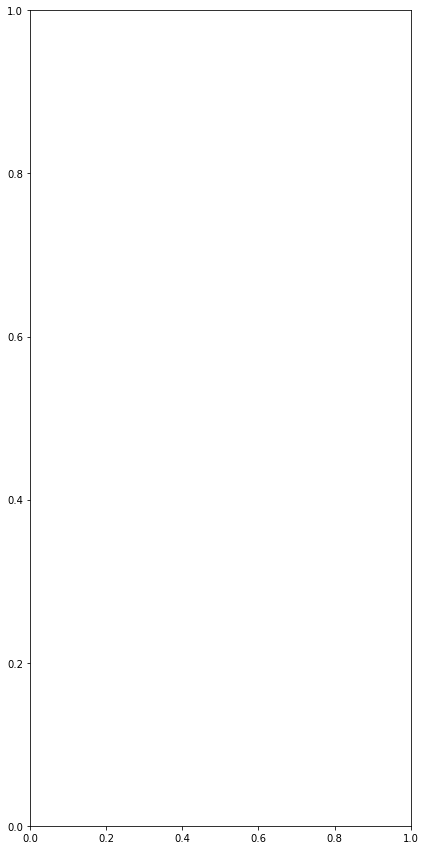

In [5]:
tmp = BlockDataContainer(*[data, data, data, data])
# print(tmp[0].as_array())                         
# plotter2D(tmp)

In [ ]:
setattr(DataContainer, "show", plotter2D)

In [ ]:

data.show()
data.show(channel=34)


plotter2D(data)

plt.figure()
plt.imshow(data)
plt.show()











In [10]:
from cil.framework import DataContainer, BlockDataContainer
from mpl_toolkits.axes_grid1 import make_axes_locatable
def show(self, **kwargs):
        
    # default title, cmap, font_size, minmax
    title = kwargs.get('title', None)
    cmap = kwargs.get('cmap', None)
    font_size_labels = kwargs.get('font_size_labels', 12)
    font_size_title = kwargs.get('font_size_title', 12)
    minmax = (kwargs.get('minmax', (self.min(),self.max())))
         
    # labels    
    labels = kwargs.get('labels', self.dimension_labels) 
        
    # defautl figure_size
    figure_size = kwargs.get('figure_size', (10,5)) 
        
    if isinstance(self, DataContainer):
        
        # show 2D via plt
        fig, ax = plt.subplots(figsize = figure_size)  
        im = ax.imshow(self.array, vmin=min(minmax), vmax=max(minmax))
        ax.set_title(title, fontsize = font_size_title)
        ax.set_xlabel(labels[0], fontsize = font_size_labels)
        ax.set_ylabel(labels[1], fontsize = font_size_labels) 
        fig.colorbar(im)
        plt.show()
        
    elif isinstance(self, BlockDataContainer):
        
        # default shape
        shape = kwargs.get('shape', (len(self),1))         
        
        fig, ax = plt.subplots(shape,figsize = figure_size)  
        im = ax.imshow(self.array, vmin=min(minmax), vmax=max(minmax))
        ax.set_title(title, fontsize = font_size_title)
        ax.set_xlabel(labels[0], fontsize = font_size_labels)
        ax.set_ylabel(labels[1], fontsize = font_size_labels) 
        fig.colorbar(im)
        plt.show()
        
        
#         divider = make_axes_locatable(ax) 
#         cax1 = divider.append_axes("right", size="5%", pad=0.1)  
#         fig.colorbar(im, ax=ax, cax = cax1)
#         fig.colorbar(im)
#         plt.show()       
        
        
    
    
setattr(DataContainer, "show", plotter2D)
# setattr(BlockDataContainer, "show", show)

data.show(title="sadfaf")
# plotter2D(data, titles=["rwe"])

# plotter2D([data,data,data], origin='upper-left')


# (1,3)
# (3,1)

# plotter2D([data, data, data,, data], ncols=1)
# plotter2D([data, data, data,, data], ncols=3)



# plotter2D([data, data, data,, data], shape=(4,1))
# plotter2D([data, data, data,, data], shape=(1,4))
# plotter2D([data, data, data,, data], shape=(5,2))
# tmp = [data, data]
# tmp = BlockDataContainer(*[data, data, data, data], shape=(2,2))
# i.show() for i in tmp]    
    
    
    
plotter2D(BlockDataContainer(*[data, data, data, data])    
    
    

TypeError: plotter2D() got an unexpected keyword argument 'title'

In [5]:
def plotter2D_new(datacontainers, titles=None, fix_range=False, stretch_y=False, 
              cmap='gray', axis_labels=None, 
              custom_range=None, 
              origin='lower-left', **kwargs):
    
    
    '''plotter2D(datacontainers=[], titles=[], fix_range=False, stretch_y=False, cmap='gray', axes_labels=['X','Y'])
    
    plots 1 or more 2D plots in an (n x 2) matix
    multiple datasets can be passed as a list
    
    Can take ImageData, AquistionData or numpy.ndarray as input
    '''
    if(isinstance(datacontainers, list)) is False:
        datacontainers = [datacontainers]

    if titles is not None:
        if(isinstance(titles, list)) is False:
            titles = [titles]
            
    rows = kwargs.get('nrows',1)
    cols = kwargs.get('ncols',1)
    figsize = kwargs.get('figsize',(15,15))
    
    if len(datacontainers)!=rows*cols:
        raise ValueError("efrwgerg")
    
#     nplots = len(datacontainers)
#     rows = int(round((nplots+0.5)/2.0))
    
#     nrows = 

    if rows>1 or cols>1:

        fig, ax = plt.subplots(rows, cols, figsize=figsize)

        axes = ax.flatten() 
        
    else:
        fig, ax = plt.subplots(rows, cols, figsize=figsize)
        axes = ax

    range_min = float("inf")
    range_max = 0
    
    if fix_range == True:
        for i in range(nplots):
            if type(datacontainers[i]) is numpy.ndarray:
                dc = datacontainers[i]
            else:
                dc = datacontainers[i].as_array()
                
            range_min = min(range_min, numpy.amin(dc))
            range_max = max(range_max, numpy.amax(dc))
        
    if custom_range is not None:
        if len(custom_range) == 2:
            range_min = custom_range[0]
            range_max = custom_range[1]

    for i in range(rows*2):
        axes[i].set_visible(False)

    for i in range(nplots):
        axes[i].set_visible(True)
        
        if titles is not None:
            axes[i].set_title(titles[i])
       
        if axis_labels is not None:
            axes[i].set_ylabel(axis_labels[1])
            axes[i].set_xlabel(axis_labels[0]) 
            
        if type(datacontainers[i]) is numpy.ndarray:
            dc = datacontainers[i]          
        else:
            dc = datacontainers[i].as_array()
            
            if axis_labels is None:
                axes[i].set_ylabel(datacontainers[i].dimension_labels[0])
                axes[i].set_xlabel(datacontainers[i].dimension_labels[1])  

        
        #set origin
        shape_v = [0,dc.shape[0]]
        shape_h = [0,dc.shape[1]]

        data_origin='lower'
        data_plot = dc

        if 'upper' in origin:
            shape_v.reverse()
            data_origin='upper'

        if 'right' in origin:
            shape_h.reverse()
            data_plot = numpy.flip(data_plot,1)

        extent = (*shape_h,*shape_v)
        
        sp = axes[i].imshow(data_plot, cmap=cmap, origin=data_origin, extent=extent)
        
        y_axes2 = False
        if isinstance(datacontainers[i],(AcquisitionData)):
            if axes[i].get_ylabel() == 'angle':
                locs = axes[i].get_yticks()
                location_new = locs[0:-1].astype(int)

                ang = datacontainers[i].geometry.config.angles

                labels_new = [str(i) for i in numpy.take(ang.angle_data, location_new)]
                axes[i].set_yticklabels(labels_new)
                
                axes[i].set_ylabel('angle / ' + str(ang.angle_unit))

                y_axes2 = axes[i].axes.secondary_yaxis('right')
                y_axes2.set_ylabel('angle / index')

        
        im_ratio = dc.shape[0]/dc.shape[1]
        
        if stretch_y ==True:   
            axes[i].set_aspect(1/im_ratio)
            im_ratio = 1

        if y_axes2: 
            scale = 0.041*im_ratio
            pad = 0.12
        else:
            scale = 0.0467*im_ratio
            pad = 0.02

        plt.colorbar(sp, orientation='vertical', ax=axes[i],fraction=scale, pad=pad)

        if fix_range == True or custom_range is not None:
            sp.set_clim(range_min,range_max)
    plt.show()


TypeError: 'AxesSubplot' object is not subscriptable

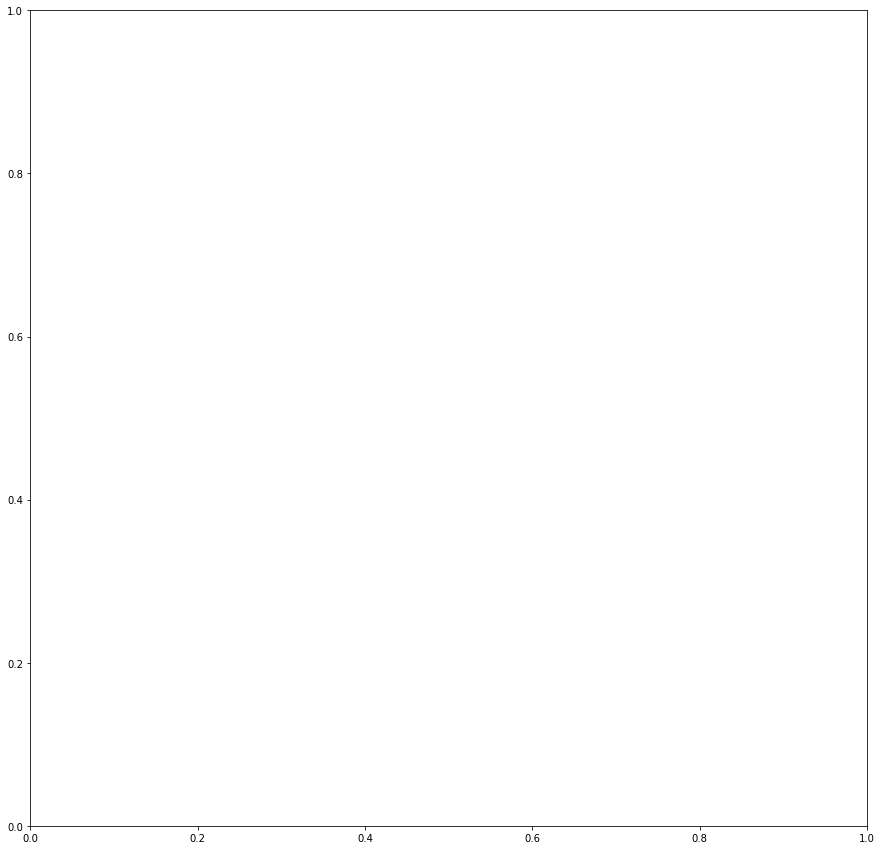

In [6]:
plotter2D_new(data)

# fig, ax = plt.subplots(2, 1)

# axes = ax.flatten() 

# from cil.framework import DataContainer

# def show(self):
#     plotter2D(self)

# setattr(DataContainer, "show", show)

# data.show()


In [26]:
from cil.framework import DataContainer
@add_method(DataContainer)
def show(array):
    plotter2D()
    
data.show(data.array)    


NameError: name 'add_method' is not defined